# 价格比率 Price Ratios：账市比 (BM) 与 盈市比 (EP)

**来源**: 移植自 `Basic Code/06 价格比率 Price Ratio/06 Price Ratios 价格比率.ipynb`，只保留 BM 与 EP 两个指标，并重写了计算引擎。

本 notebook 计算两个个股层面的价格比率（及对应的市场层面加总序列）：

1. **账市比 `bm` (book-to-market)** — 最近一期已公布财报的所有者权益（剔除优先股）÷ 当月**按 A 股价格计的公司总市值**（= `floatingvalue / ratio`）；
   同时给出资产市值比 `am`（总资产 ÷ 同一市值）。
2. **盈市比 EP (earnings-to-price)** — 两种口径（注意分母不同，沿用原版定义）：
   - `ep_recent`：**最近一期已公布财报**的扣非净利润（YTD 口径）÷ 当月**总市值** `totalvalue`；
   - `ep`：**最近四个完整会计季度**（TTM）的扣非净利润 ÷ 当月**按 A 股价格计的公司总市值**。
     对含 B/H 股的公司两种分母可差 25–40%（如工商银行 `ratio≈0.75` 而 `floatingvalue/totalvalue≈1`）。

> **中国市场的制度背景**：上市公司自 2002 年起才强制披露季报，此前只有年报和半年报。
> 因此单季利润（YTD 差分）只能从 2002 年算起；TTM 口径在 **2003 年 5 月之前**退化为
> "最近一个完整会计年度"（最新已公布年报）的利润。

## 相对原版的性能优化

| 优化点 | 原版 | 现版 |
|---|---|---|
| 单季利润差分 | `ddply` 按 (股票, 季度) 逐行循环查表 | 分组 `shift()` 向量化差分 |
| EP 逐月匹配最近财报 | `ddply` 按 (股票, 月份) 逐行子集查找（慢到只能逐年增量更新再 `rbind` 旧缓存）；BM 部分原版已是非等值连接 | 非等值 as-of 连接一次完成 |
| 财务报表读取 | `read.csv` 全列读入（资产负债表 654MB / 利润表 353MB） | `fread(select=)` 只读所需列 |
| 月末股数比例 `ratio` | `readRDS` 加载 1,500 万行日度全表 | `feather` 按列读取 5 列 |
| 财报公布日期 | `openxlsx::read.xlsx` | `readxl::read_excel` |

全样本（1991–2025，86.8 万个股票-月）从原始数据到全部结果约 **15 秒**，且为全量重算，
不再依赖旧年度缓存（旧缓存会携带过时的数据版本，见文末验证一节）。

## 0. 准备数据

**月度收益与市值** `Output/ret_mon2025.RDS`
- `floatingvalue` [流通市值]、`totalvalue` [总市值]、`Return` [月收益率]

**日度数据（仅取月末快照）** `Output/ret_day2025.feather`
- `ratio` = A 股流通股数 / 总股数（`A_float_shares / All_shares`），`yuemo` = 月末交易日标记
- 注意 `ratio` 是**股数**比例而非市值比例：`bookvalue × ratio / floatingvalue` 等价于
  "账面价值 ÷ 按 A 股价格计的公司总市值"，对含 B/H 股的公司与 `floatingvalue/totalvalue` 差异很大

**财报公布日期** CSMAR ➡️ 公司研究系列 ➡️ 年、中、季报公布日期 ➡️ 基本情况文件 `IAR_Rept2025.xlsx`
- `Stkcd` [证券代码]、`Accper` [统计截止日期]、`Annodt` [报告公布日期]（前两行为中文表头与单位，需剔除）

In [1]:
suppressMessages({
    library(data.table)
    library(zoo)        # yearmon / yearqtr
    library(readxl)     # 读 xlsx, 远快于 openxlsx
    library(arrow)      # 读 feather
    library(stringr)
    library(ggplot2)
})

DATA <- '/Volumes/BetAlpha/Asset Pricing/Data'
OUT  <- 'output'                                  # 结果保存到本仓库 output/ 目录
dir.create(OUT, showWarnings = FALSE)
t0 <- proc.time()
elapsed <- function(msg) cat(sprintf('%s  [累计 %.1f 秒]\n', msg, (proc.time() - t0)[3]))

# 月度收益与市值: 只取需要的列
ret_mon <- readRDS(file.path(DATA, 'Output/ret_mon2025.RDS'))[
    , .(Stkcd, month, Return, floatingvalue, totalvalue)]

# 月末 ratio(A股流通股数/总股数) 与收盘价: feather 按列读取, 避免加载 1,500 万行全表
rd <- read_feather(file.path(DATA, 'Output/ret_day2025.feather'),
                   col_select = c('Stkcd', 'month', 'yuemo', 'ratio', 'Clsprc'))
setDT(rd)
rd <- rd[yuemo == 1, .(Stkcd, month, ratio, Clsprc)]

# 财报的发布时间: 前两行是中文表头与单位说明, 剔除
account_date <- as.data.table(read_excel(
    file.path(DATA, 'Input/Report_Date/IAR_Rept2025.xlsx'), col_types = 'text'))[
    -(1:2), .(Stkcd, Accper, report_date = Annodt)]
account_date[, `:=`(Accper = as.Date(Accper), report_date = as.Date(report_date))]
account_date[, Q := as.yearqtr(Accper)]

elapsed(sprintf('数据准备完成: ret_mon %s 行 | 月末 ratio %s 行 | 财报日期 %s 行',
    format(nrow(ret_mon), big.mark = ','), format(nrow(rd), big.mark = ','),
    format(nrow(account_date), big.mark = ',')))

数据准备完成: ret_mon 868,010 行 | 月末 ratio 791,687 行 | 财报日期 292,512 行  [累计 5.2 秒]


## 1. 账市比 (Book-to-Market Ratio)

**资产负债表** CSMAR ➡️ 公司研究系列 ➡️ 财务报表 ➡️ 资产负债表 `FS_Combas2025.csv`
- `Typrep` [报表类型]：A = 合并报表（仅保留），B = 母公司报表
- `A001000000` [资产总计]、`A003000000` [所有者权益合计]
- `A003112101` [其中：优先股]（2015 年起使用）：账面价值 = 所有者权益 − 优先股

**计算**：对每个股票-月份，取**公布日 ≤ 当月**的最近一期财报：

$$bm_{i,t} = \frac{\text{bookvalue}_{i,\,latest}\times ratio_{i,t}}{\text{floatingvalue}_{i,t}}\,,\qquad
am_{i,t} = \frac{\text{totalasset}_{i,\,latest}\times ratio_{i,t}}{\text{floatingvalue}_{i,t}}$$

即账面价值除以"按 A 股价格计的公司总市值"。

> **沿用原版的一个细节**：BM 取的是**公布时间最晚**的一期财报，而第 2 节 EP 取的是已公布报告中
> **会计期间最新**的一期。当旧会计期间的报告晚于新报告公布时（如部分公司 2019 年报因疫情迟至
> 2020Q1 季报之后才公布），两者会选中不同的报告——全样本约 233 个股票-月（0.03%）受影响。
> 为与原版输出保持 100% 一致，此处保留原版行为。

In [2]:
# 资产负债表: 654MB 的 CSV 用 fread(select=) 只读 6 列
Balance_sheet <- fread(file.path(DATA, 'Input/Balance_Sheet/FS_Combas2025.csv'),
    select = c('Stkcd', 'Accper', 'Typrep', 'A001000000', 'A003000000', 'A003112101'),
    colClasses = list(character = c('Stkcd', 'Accper', 'Typrep')))

Balance_sheet <- Balance_sheet[Typrep == 'A'][, Typrep := NULL]     # 只保留合并报表
# 账面价值 = 所有者权益合计 - 优先股(字段 2015 年起才有, 缺失时即权益合计)
Balance_sheet[, `:=`(
    Stkcd     = str_pad(Stkcd, 6, side = 'left', pad = '0'),
    bookvalue = fifelse(is.na(as.numeric(A003112101)),
                        as.numeric(A003000000),
                        as.numeric(A003000000) - as.numeric(A003112101)))]
setnames(Balance_sheet, c('Accper', 'A001000000'), c('Q', 'totalasset'))
Balance_sheet <- Balance_sheet[, .(Stkcd, Q, bookvalue, totalasset)]
Balance_sheet[, `:=`(Q = as.Date(Q), totalasset = as.numeric(totalasset))]
Balance_sheet <- Balance_sheet[month(Q) > 1]                        # 剔除 1 月截止的异常会计期间
Balance_sheet[, Q := as.yearqtr(Q)]

# 合并财报公布日期(转为公布月)
Balance_sheet <- merge(Balance_sheet, account_date[, .(Stkcd, Q, report_date)],
                       by = c('Stkcd', 'Q'), all.x = TRUE)
Balance_sheet[, report_date := as.yearmon(report_date)]

elapsed(sprintf('资产负债表就绪: %s 行', format(nrow(Balance_sheet), big.mark = ',')))

资产负债表就绪: 295,889 行  [累计 75.8 秒]


In [3]:
# 个股月度 BM: 非等值 as-of 连接, 对每个股票-月份取"公布日 <= 当月"的最近一期财报
ret_mon_bm <- merge(ret_mon[, .(Stkcd, month, floatingvalue)],
                    rd[, .(Stkcd, month, ratio)], by = c('Stkcd', 'month'), all.x = TRUE)

setorder(Balance_sheet, Stkcd, report_date)       # 预排序后, 连接中 last() 即最近公布的一期
BM_individual_mon <- Balance_sheet[
    ret_mon_bm,
    on = .(Stkcd, report_date <= month),          # 非等值连接: 财报公布月 <= 当前月
    .(bm = data.table::last(bookvalue) * ratio / floatingvalue,
      am = data.table::last(totalasset) * ratio / floatingvalue),
    by = .EACHI                                   # 对每个股票-月份组合单独计算
][, .(Stkcd, month = report_date, bm, am)]
BM_individual_mon[is.na(bm), c('bm', 'am') := .(NA_real_, NA_real_)]

# 季度版本: 取 3/6/9/12 月末值
BM_individual_qrt <- BM_individual_mon[cycle(month) %in% c(3, 6, 9, 12)][
    , Q := as.yearqtr(month)][, .(Stkcd, Q, bm, am)]

elapsed(sprintf('BM 个股面板: %s 行', format(nrow(BM_individual_mon), big.mark = ',')))
head(BM_individual_mon[!is.na(bm)])

BM 个股面板: 868,010 行  [累计 146.9 秒]


Stkcd,month,bm,am
<chr>,<yearmon>,<dbl>,<dbl>
000001,Apr 1991,0.1116410,1.377960
000001,May 1991,0.1271903,1.569882
000001,Jun 1991,0.1434680,1.770794
000001,Jul 1991,0.1650805,2.037552
000001,Aug 1991,0.1756774,2.168347
000001,Sep 1991,0.1817352,2.243117


In [4]:
# 市场层面: 流通市值加权的 log(P/B)
Price_bookvalue_mon <- merge(ret_mon[, .(Stkcd, month, floatingvalue)],
                             BM_individual_mon, by = c('Stkcd', 'month'), all.x = TRUE)[
    bm > 0,
    .(pb = log(sum(floatingvalue, na.rm = TRUE) / sum(floatingvalue * bm, na.rm = TRUE))),
    by = 'month'][order(month)]

Price_bookvalue_qtr <- Price_bookvalue_mon[cycle(month) %in% c(3, 6, 9, 12)][
    , Q := as.yearqtr(month)][, .(Q, pb)]

tail(Price_bookvalue_mon)

month,pb
<yearmon>,<dbl>
Jul 2025,0.3154603
Aug 2025,0.3934753
Sep 2025,0.4056446
Oct 2025,0.4011423
Nov 2025,0.3857147
Dec 2025,0.4115416


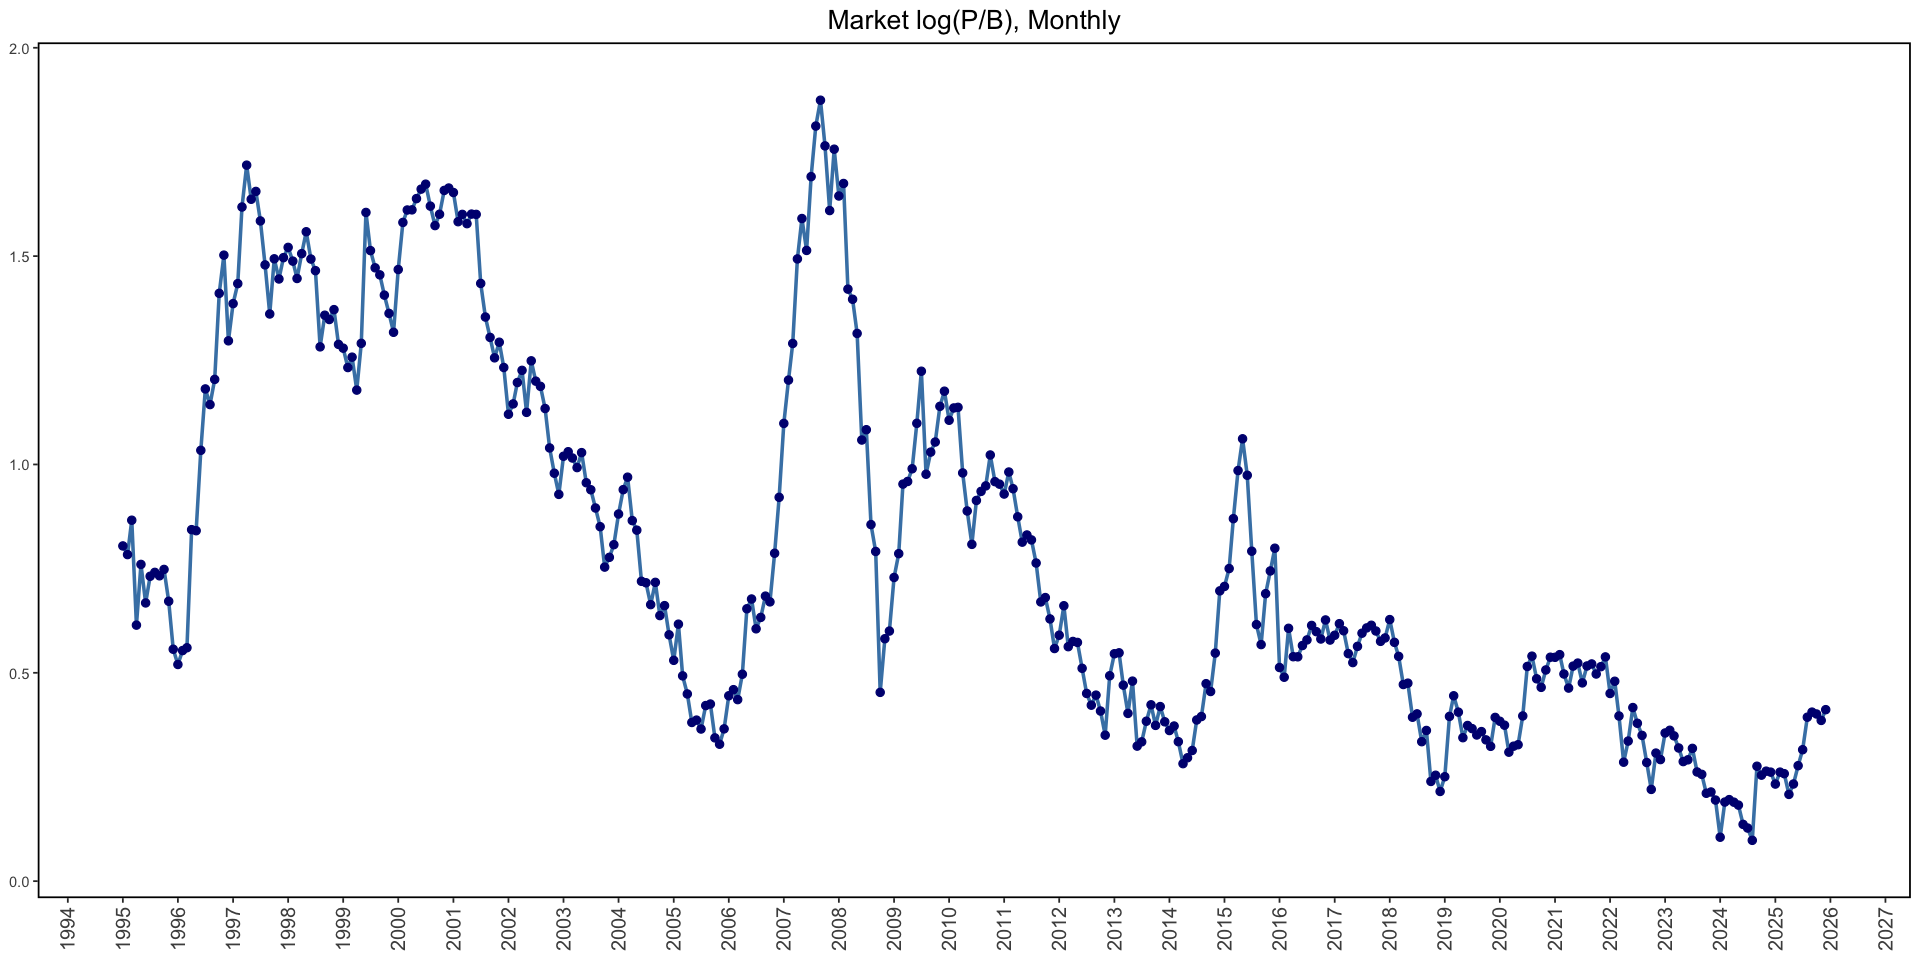

In [5]:
# 月度 log(P/B) 时序图
options(repr.plot.width = 16, repr.plot.height = 8)
plot_pb <- Price_bookvalue_mon[month >= as.yearmon('1995-01')][, .(month = as.Date(month), pb)]
ggplot(plot_pb, aes(x = month, y = pb)) +
    geom_line(color = 'steelblue', linewidth = 1) +
    geom_point(color = 'navy', size = 2) +
    labs(title = 'Market log(P/B), Monthly') +
    scale_x_date(date_breaks = '1 year', date_labels = '%Y') +
    theme(
        plot.title = element_text(hjust = 0.5, size = 16),
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 12),
        panel.border = element_rect(color = 'black', fill = NA, linewidth = 1),
        panel.background = element_blank(),
        plot.background = element_blank(),
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank()
    ) +
    scale_y_continuous(expand = c(0.05, 0.05))

## 2. 盈市比 (Earnings-to-Price Ratio)

**利润表** `FS_Comins2025.csv`：`B002000000` [净利润]（YTD 累计口径）

**非经常性损益** CSMAR ➡️ 公司研究系列 ➡️ 财务指标分析 ➡️ 披露财务指标 `FI_T22025.csv`：
`F020101` [非经常性损益]。本文使用 **扣非净利润** `earnings = B002000000 − F020101`（缺失时用净利润）。

### 两种口径

| 口径 | 含义 | 计算 |
|---|---|---|
| `ep_recent` | 最近一期已公布财报的利润 | `recent_earnings / totalvalue` |
| `ep` | 最近四个完整会计季度 (TTM) 的利润 | `matchearnings × ratio / floatingvalue` |

### TTM 的构造（处理中国数据的特殊性）

中国财报利润是**年初至今 (YTD) 累计值**，需先差分出单季利润：

1. **单季利润** `Q_earnings`：Q1 直接用 YTD；Q2/Q3/Q4 = 当期 YTD − 上一季 YTD（上一季缺失则 NA）；
   **2002 年之前没有季报，单季利润一律 NA**。
2. **TTM** `ttm`：连续 4 个会计季度的单季利润之和（任何一个季度缺失或不连续则 NA）。
3. **逐月匹配** `matchearnings`：对每个股票-月份，取公布日 ≤ 当月的最近一期财报（按会计期间最大者）：
   - **2003-05 及之后**：用该期的 `ttm`（2002 全年季报 + 2003Q1 季报到 2003 年 4 月底全部公布完毕，
     此后 TTM 口径才对全市场可行）；
   - **2003-05 之前**：退化为"最近一个完整会计年度"——最新**已公布**年报的利润
     （若最新一期财报本身是年报即其本身，否则须是上一年度年报；不满足则 NA）。

In [6]:
# 利润表: 353MB CSV 只读 4 列; 净利润缺失的行剔除; 只保留合并报表
Profit <- fread(file.path(DATA, 'Input/Profit/FS_Comins2025.csv'),
    select = c('Stkcd', 'Accper', 'Typrep', 'B002000000'),
    colClasses = list(character = c('Stkcd', 'Accper', 'Typrep')))
Profit <- na.omit(Profit)[Typrep == 'A'][, Typrep := NULL]
Profit[, Accper := as.Date(Accper)]

# 非经常性损益
fi <- fread(file.path(DATA, 'Input/Non_recurring_gains_and_losses/FI_T22025.csv'),
    select = c('Stkcd', 'Accper', 'F020101'),
    colClasses = list(character = c('Stkcd', 'Accper')))
fi[, Accper := as.Date(Accper)]

Profit <- merge(Profit, fi, by = c('Stkcd', 'Accper'), all.x = TRUE)
setnames(Profit, 'Accper', 'Q')
Profit <- Profit[month(Q) > 1]                     # 剔除 1 月截止的异常会计期间
Profit[, Q := as.yearqtr(Q)]
setorder(Profit, Stkcd, Q)

# ---- 手工数据修正(沿用原版) ----
# 600015 华夏银行 2015Q1 非经常性损益在 CSMAR 中单位错误(2026.1 检查仍未修复)
Profit[Stkcd == '600015' & Q == as.yearqtr('2015 Q1'), F020101 := as.numeric(F020101) / 1e5]

# earnings = 扣非净利润; 无非经常性损益数据时退回净利润
Profit[, earnings := fifelse(!is.na(F020101),
                             as.numeric(B002000000) - as.numeric(F020101),
                             as.numeric(B002000000))]
Profit[, Stkcd := str_pad(Stkcd, 6, side = 'left', pad = '0')]

# 合并财报公布日期
Profit <- merge(Profit, account_date[, .(Stkcd, Q, report_date)], by = c('Stkcd', 'Q'), all.x = TRUE)
Profit[, report_date := as.yearmon(report_date)]
# 601939 建设银行 2016Q1 公布日期缺失, 手工补为 2016-04 (2023.12.20 发现)
Profit[Stkcd == '601939' & Q == as.yearqtr('2016 Q1'), report_date := as.yearmon('2016-04')]

elapsed(sprintf('利润表就绪: %s 行, (Stkcd, Q) 重复: %d',
    format(nrow(Profit), big.mark = ','), sum(duplicated(Profit, by = c('Stkcd', 'Q')))))

利润表就绪: 295,772 行, (Stkcd, Q) 重复: 0  [累计 276.2 秒]


In [7]:
# ---- 单季利润: YTD 差分(分组 shift 向量化, 替代原版 ddply 逐行循环) ----
setorder(Profit, Stkcd, Q)
Profit[, Qn := as.numeric(Q)]                     # yearqtr 数值: Q1=.00 Q2=.25 Q3=.50 Q4=.75
Profit[, `:=`(prevQ = shift(Qn), prevE = shift(earnings)), by = Stkcd]
Profit[, Q_earnings := fcase(
    floor(Qn) < 2002,                              NA_real_,          # 2002 年前无季报
    Qn %% 1 == 0,                                  earnings,          # Q1: YTD 即单季
    !is.na(prevQ) & abs(Qn - prevQ - 0.25) < 1e-9, earnings - prevE,  # 上一季存在才能差分
    default = NA_real_)]

# ---- TTM: 连续 4 个会计季度的单季利润之和 ----
Profit[, `:=`(qe1 = shift(Q_earnings, 1), qe2 = shift(Q_earnings, 2), qe3 = shift(Q_earnings, 3),
              Q1n = shift(Qn, 1),         Q2n = shift(Qn, 2),         Q3n = shift(Qn, 3)),
       by = Stkcd]
Profit[, ttm := fifelse(
    !is.na(Q1n) & !is.na(Q2n) & !is.na(Q3n) &
    abs(Qn - Q1n - 0.25) < 1e-9 & abs(Qn - Q2n - 0.50) < 1e-9 & abs(Qn - Q3n - 0.75) < 1e-9,
    Q_earnings + qe1 + qe2 + qe3, NA_real_)]      # 季度不连续或任一单季 NA → NA
Profit[, c('prevQ', 'prevE', 'qe1', 'qe2', 'qe3', 'Q1n', 'Q2n', 'Q3n') := NULL]

elapsed('单季利润与 TTM 计算完成')
Profit[Stkcd == '000001' & Qn >= 2002 & Qn < 2004,
       .(Stkcd, Q, earnings, Q_earnings, ttm, report_date)]

单季利润与 TTM 计算完成  [累计 329.5 秒]


Stkcd,Q,earnings,Q_earnings,ttm,report_date
<chr>,<yearqtr>,<dbl>,<dbl>,<dbl>,<yearmon>
000001,2002 Q1,183951144,183951144,NA,Apr 2002
000001,2002 Q2,314141342,130190198,NA,Aug 2002
000001,2002 Q3,419642032,105500690,NA,Oct 2002
000001,2002 Q4,432224930,12582898,432224930,Apr 2003
000001,2003 Q1,153313141,153313141,401586927,Apr 2003
000001,2003 Q2,270340697,117027556,388424285,Aug 2003
000001,2003 Q3,314953470,44612773,327536368,Oct 2003
000001,2003 Q4,316545704,1592234,316545704,Apr 2004


In [9]:
# ---- 逐月匹配最近一期已公布财报: 非等值 as-of 连接(替代原版逐股票-月份循环) ----
released <- Profit[!is.na(report_date), .(Stkcd, Qn, report_date, earnings, ttm)]
setorder(released, Stkcd, report_date, Qn)

# 会计期间的运行最大值过滤: 公布晚于更新报告的旧报告(更正公告等)永远不会成为
# "最近一期", 剔除后 as-of 连接取最后一行即 max(会计期间)
prof_asof <- copy(released)[, cmax := cummax(Qn), by = Stkcd][Qn >= cmax][, cmax := NULL]

# 年报子表(2003-05 之前的回退口径): 必须从完整的已公布集合构建, 否则晚公布的年报
# (如青岛啤酒 1995 年报迟至 1996-11 公布, 晚于 1996 半年报)会被上面的过滤误删
ann <- released[Qn %% 1 == 0.75][, cmaxA := cummax(Qn), by = Stkcd][Qn >= cmaxA][, cmaxA := NULL]

# as-of 连接: 对 ret_mon 的每个股票-月份取 report_date <= month 的最后一条
j1 <- prof_asof[ret_mon, on = .(Stkcd, report_date <= month), mult = 'last',
    .(Stkcd = i.Stkcd, month = i.month, Return = i.Return,
      floatingvalue = i.floatingvalue, totalvalue = i.totalvalue,
      Q0 = x.Qn, recent_earnings = x.earnings, ttm = x.ttm)]
j2 <- ann[ret_mon, on = .(Stkcd, report_date <= month), mult = 'last',
    .(Qa = x.Qn, earnings_a = x.earnings)]
EP_individual_mon <- cbind(j1, j2)

# 2003-05 之前的回退口径: 最新已公布年报(最新财报为年报时即其本身, 否则须为上一年年报)
EP_individual_mon[, expectedA := fifelse(Q0 %% 1 == 0.75, Q0, floor(Q0) - 0.25)]
EP_individual_mon[, pre_match := fifelse(!is.na(Qa) & abs(Qa - expectedA) < 1e-9,
                                         earnings_a, NA_real_)]

# matchearnings: 最近四个完整会计季度的利润; recent_earnings: 最近一期财报利润(YTD 口径)
EP_individual_mon[, matchearnings := fifelse(month >= as.yearmon('2003-05'), ttm, pre_match)]
# 与原版一致: 当月无收益记录(停牌/上市首月等)不计算
EP_individual_mon[is.na(Return), `:=`(matchearnings = NA_real_, recent_earnings = NA_real_)]

# 合并月末 ratio 与收盘价, 计算两种口径的 EP
EP_individual_mon <- merge(EP_individual_mon, rd, by = c('Stkcd', 'month'), all.x = TRUE)
EP_individual_mon[, `:=`(
    ep        = matchearnings * as.numeric(ratio) / as.numeric(floatingvalue),  # TTM 口径
    ep_recent = recent_earnings / as.numeric(totalvalue))]                      # 最近财报口径
EP_individual_mon <- EP_individual_mon[, .(Stkcd, month, matchearnings, recent_earnings,
                                           floatingvalue, totalvalue, ratio, Clsprc, ep, ep_recent)]

# 季度版本
EP_individual_qtr <- EP_individual_mon[cycle(month) %in% c(3, 6, 9, 12)][
    , Q := as.yearqtr(month)][
    , .(Stkcd, Q, matchearnings, recent_earnings, floatingvalue, totalvalue,
        ratio, Clsprc, ep, ep_recent)]

elapsed(sprintf('EP 个股面板: %s 行', format(nrow(EP_individual_mon), big.mark = ',')))
tail(EP_individual_mon[!is.na(ep)])

EP 个股面板: 868,010 行  [累计 415.0 秒]


Stkcd,month,matchearnings,recent_earnings,floatingvalue,totalvalue,ratio,Clsprc,ep,ep_recent
<chr>,<yearmon>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
605599,Jul 2025,719540412,282201243,11791111450,11791111450,1,15.16,0.06102397,0.02393339
605599,Aug 2025,708134921,406176159,10850000310,10850000310,1,13.95,0.06526589,0.03743559
605599,Sep 2025,708134921,406176159,10958889200,10958889200,1,14.09,0.06461740,0.03706362
605599,Oct 2025,761092716,599331883,11215555880,11215555880,1,14.42,0.06786045,0.05343755
605599,Nov 2025,761092716,599331883,12063333680,12063333680,1,15.51,0.06309141,0.04968211
605599,Dec 2025,761092716,599331883,12732222590,12732222590,1,16.37,0.05977689,0.04707206


In [10]:
# 市场层面: 流通市值加权 log(P/E), 仅用正盈利股票
Price_earnings_mon <- EP_individual_mon[ep > 0,
    .(pe = log(sum(floatingvalue, na.rm = TRUE) / sum(floatingvalue * ep, na.rm = TRUE))),
    by = 'month'][order(month)]
Price_earnings_qtr <- EP_individual_qtr[ep > 0,
    .(pe = log(sum(floatingvalue, na.rm = TRUE) / sum(floatingvalue * ep, na.rm = TRUE))),
    by = 'Q'][order(Q)]

tail(Price_earnings_mon)

month,pe
<yearmon>,<dbl>
Jul 2025,2.717347
Aug 2025,2.793736
Sep 2025,2.807271
Oct 2025,2.796065
Nov 2025,2.777819
Dec 2025,2.804397


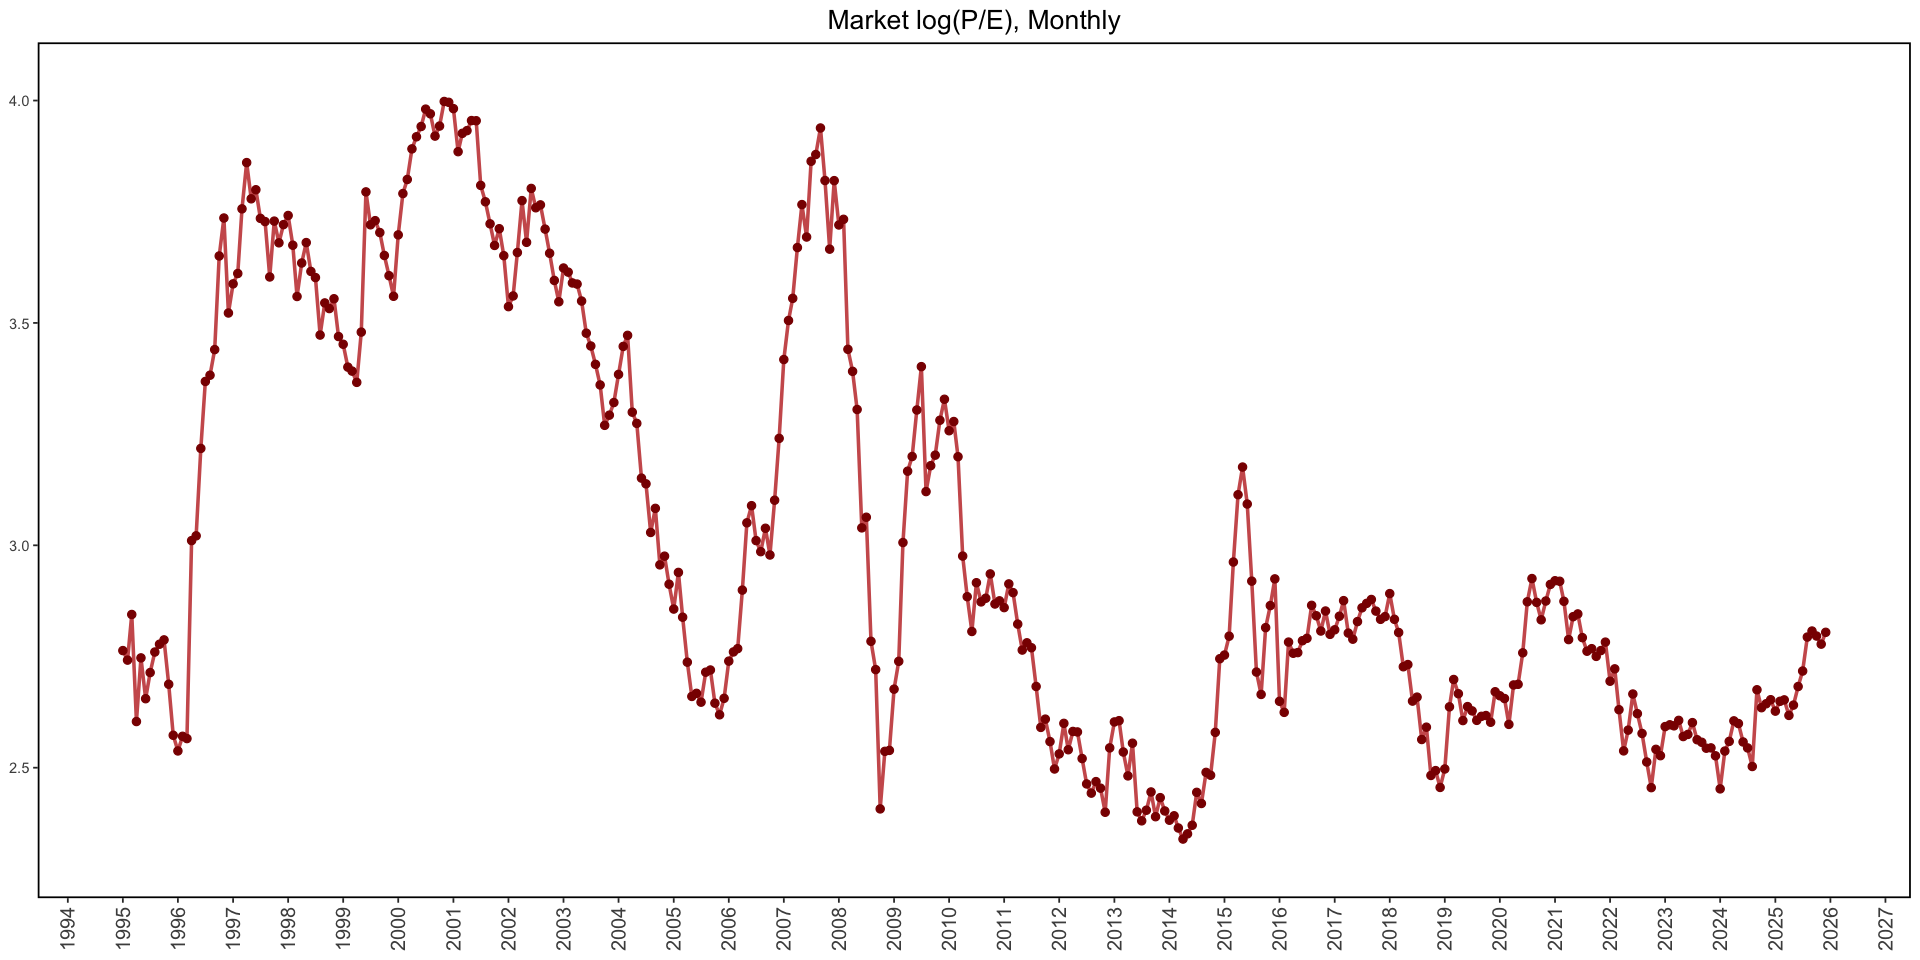

In [11]:
# 月度 log(P/E) 时序图
options(repr.plot.width = 16, repr.plot.height = 8)
plot_pe <- Price_earnings_mon[month >= as.yearmon('1995-01')][, .(month = as.Date(month), pe)]
ggplot(plot_pe, aes(x = month, y = pe)) +
    geom_line(color = 'indianred', linewidth = 1) +
    geom_point(color = 'darkred', size = 2) +
    labs(title = 'Market log(P/E), Monthly') +
    scale_x_date(date_breaks = '1 year', date_labels = '%Y') +
    theme(
        plot.title = element_text(hjust = 0.5, size = 16),
        axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 12),
        panel.border = element_rect(color = 'black', fill = NA, linewidth = 1),
        panel.background = element_blank(),
        plot.background = element_blank(),
        axis.title.x = element_blank(),
        axis.title.y = element_blank(),
        panel.grid.major = element_blank(),
        panel.grid.minor = element_blank()
    ) +
    scale_y_continuous(expand = c(0.05, 0.05))

## 3. 保存结果

保存为 RDS + CSV 两种格式到本仓库 `output/` 目录
（CSV 中 `yearmon`/`yearqtr` 以小数年形式存储，如 `1991.25` = 1991 年 4 月，与库内其他输出一致）。

In [12]:
save2 <- function(data, name) {
    saveRDS(data, file.path(OUT, paste0(name, '.RDS')))
    fwrite(data, file.path(OUT, paste0(name, '.csv')))
}
# 个股面板
save2(BM_individual_mon,   'BM_individual_mon')
save2(BM_individual_qrt,   'BM_individual_qrt')
save2(EP_individual_mon,   'EP_individual_mon')
save2(EP_individual_qtr,   'EP_individual_qtr')
# 市场层面时间序列
save2(Price_bookvalue_mon, 'Price_bookvalue_mon')
save2(Price_bookvalue_qtr, 'Price_bookvalue_qtr')
save2(Price_earnings_mon,  'Price_earnings_mon')
save2(Price_earnings_qtr,  'Price_earnings_qtr')

elapsed('全部完成, 结果已保存到 output/')

全部完成, 结果已保存到 output/  [累计 450.8 秒]


## 4. 与原版输出的对比验证

与原版输出 `Data/Output/{BM,EP}_individual_mon2025.RDS` 逐行对比（相对误差 < 1e-8 记为一致）。
其中 BM 文件是原版**全量**计算所得；EP 文件是原版 2022→2023→2024→2025 **逐年增量** `rbind` 拼接所得。

**已核实的结论**（2026-06 全量比对）：

- **BM / AM：868,010 行 100% 一致**。
- **EP**：`recent_earnings`/`ep_recent` 99.91% 一致；`matchearnings`/`ep` 99.4% 一致。
  **全部剩余差异来自数据版本，而非计算逻辑**——EP 旧文件逐年增量拼接，历史年份的值携带
  当年下载的旧版 CSMAR 数据（这也是 BM 能 100% 一致而 EP 不能的原因：BM 旧文件是在当前
  数据版本上全量算的）。例如万科 (000002) 2006 年报
  净利润：2022 版利润表为 2,308,440,478.62，当前 2025 版已修订为 2,154,639,315，
  旧文件 2007 年各月的 `matchearnings` 仍是旧值。本 notebook 全量重算，与**当前**数据版本一致。

In [12]:
old_bm_path <- file.path(DATA, 'Output/BM_individual_mon2025.RDS')
old_ep_path <- file.path(DATA, 'Output/EP_individual_mon2025.RDS')
releq <- function(a, b, tol = 1e-8)             # NA==NA 记为一致; 数值用相对误差判定
    (is.na(a) & is.na(b)) | (!is.na(a) & !is.na(b) & abs(a - b) <= tol * pmax(abs(a), abs(b), 1e-12))

if (file.exists(old_bm_path)) {
    cmp <- merge(readRDS(old_bm_path), BM_individual_mon, by = c('Stkcd', 'month'),
                 suffixes = c('_old', '_new'), all = TRUE)
    cat(sprintf('BM: bm 一致 %s / %s | am 一致 %s / %s\n',
        format(sum(releq(cmp$bm_old, cmp$bm_new)), big.mark = ','),
        format(nrow(cmp), big.mark = ','),
        format(sum(releq(cmp$am_old, cmp$am_new)), big.mark = ','),
        format(nrow(cmp), big.mark = ',')))
}
if (file.exists(old_ep_path)) {
    cmpe <- merge(readRDS(old_ep_path)[, .(Stkcd, month, matchearnings, recent_earnings, ep, ep_recent)],
                  EP_individual_mon[, .(Stkcd, month, matchearnings, recent_earnings, ep, ep_recent)],
                  by = c('Stkcd', 'month'), suffixes = c('_old', '_new'), all = TRUE)
    for (v in c('matchearnings', 'recent_earnings', 'ep', 'ep_recent')) {
        a <- cmpe[[paste0(v, '_old')]]; b <- cmpe[[paste0(v, '_new')]]
        cat(sprintf('EP: %-15s 一致 %s / %s\n', v,
            format(sum(releq(a, b)), big.mark = ','), format(nrow(cmpe), big.mark = ',')))
    }
}

BM: bm 一致 868,010 / 868,010 | am 一致 868,010 / 868,010


EP: matchearnings   一致 862,744 / 868,010
EP: recent_earnings 一致 867,202 / 868,010
EP: ep              一致 863,253 / 868,010
EP: ep_recent       一致 867,202 / 868,010
